In [1]:
import rasterio
import pandas as pd
import numpy as np

# Buka file GeoTIFF
tif_file = r"D:\ITB\TA\Data\Parameter\01. Air\swim_ice_consistency_0-1m.tif"

with rasterio.open(tif_file) as src:
    
    # Ambil data raster band pertama
    band = src.read(1)
    
    # Ambil ukuran raster
    rows, cols = band.shape
    
    data = []

    # Loop semua pixel
    for row in range(rows):
        for col in range(cols):
            
            # Nilai pixel
            value = band[row, col]
            
            # Skip nilai kosong (NoData)
            if value == src.nodata:
                continue
            
            # Konversi pixel ke koordinat
            lon, lat = src.xy(row, col)
            
            data.append({
                "Longitude": lon,
                "Latitude": lat,
                "Ice_Consistency": value
            })

# Ubah ke dataframe
df = pd.DataFrame(data)

# Simpan CSV
df.to_csv("ice_consistency_0-1m_bener.csv", index=False)

print("Selesai!")
print(df.head())

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Selesai!
   Longitude  Latitude  Ice_Consistency
0        0.5       0.5              0.0
1        1.5       0.5              0.0
2        2.5       0.5              0.0
3        3.5       0.5              0.0
4        4.5       0.5              0.0


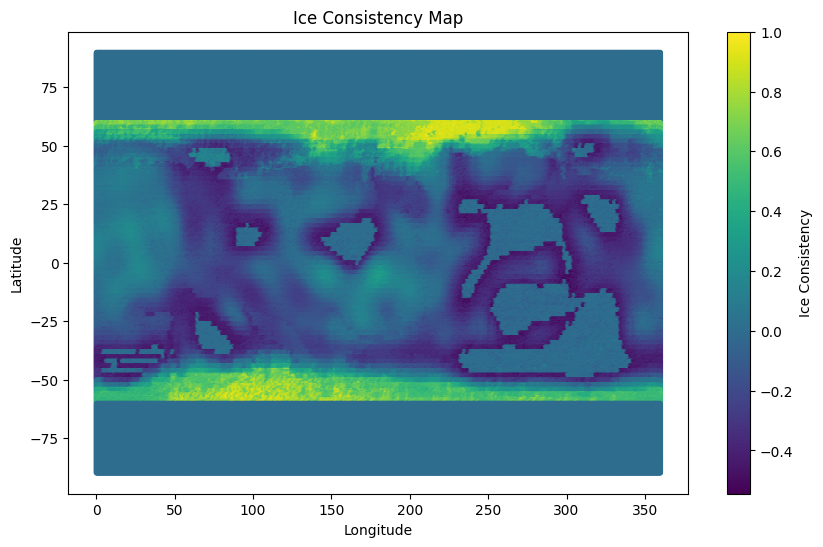

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data dari CSV
df_bersih = pd.read_csv(r"D:\ITB\TA\Ngolah Data\Ice\0-1\ice_consistency_0-1m_bener.csv")

df_bersih["Longitude"] = df_bersih["Longitude"] * 360 / 720
df_bersih["Latitude"] =90 - (df_bersih["Latitude"] * 180 / 360)

# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_bersih["Longitude"], df_bersih["Latitude"], c=df_bersih["Ice_Consistency"], cmap="viridis", s=10)
plt.colorbar(label="Ice Consistency")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Ice Consistency Map")


plt.show()

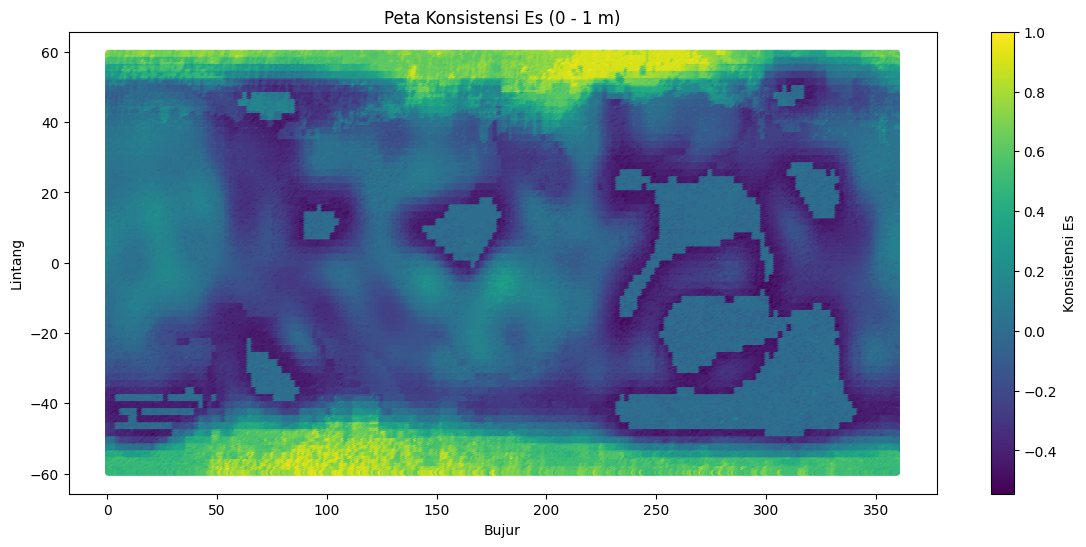

In [3]:
df_nonkutub = df_bersih[(df_bersih["Latitude"] < 60) & (df_bersih["Latitude"] > -60)]
plt.figure(figsize=(14, 6))
plt.scatter(df_nonkutub["Longitude"], df_nonkutub["Latitude"], c=df_nonkutub["Ice_Consistency"], cmap="viridis", s=10)
plt.colorbar(label="Konsistensi Es")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Konsistensi Es (0 - 1 m)")
# balik sumbu y
plt.show()

In [4]:
# hitung frekuensi
counts = df_nonkutub["Ice_Consistency"].value_counts().sort_index()

print(counts)


Ice_Consistency
-0.544545    24
-0.543636    15
-0.542727    14
-0.541818    14
-0.540909    11
             ..
 0.997886     1
 0.997964     1
 0.998182     2
 0.998486     1
 1.000000    51
Name: count, Length: 27709, dtype: int64


In [4]:
df_after0 = df_bersih[(df_bersih["Ice_Consistency"] > 0)]
print(df_after0.head())

       Longitude  Latitude  Ice_Consistency
43200       0.25     59.75         0.814755
43201       0.75     59.75         0.713845
43202       1.25     59.75         0.741932
43203       1.75     59.75         0.635168
43204       2.25     59.75         0.628795


In [6]:
counts_after0 = df_after0["Ice_Consistency"].value_counts().sort_index()

print(counts_after0)

Ice_Consistency
1.015988e-08     5
3.386627e-08     7
9.998340e-05     1
1.415238e-04     2
1.863695e-04     1
                ..
9.978864e-01     1
9.979636e-01     1
9.981818e-01     2
9.984863e-01     1
1.000000e+00    51
Name: count, Length: 21270, dtype: int64


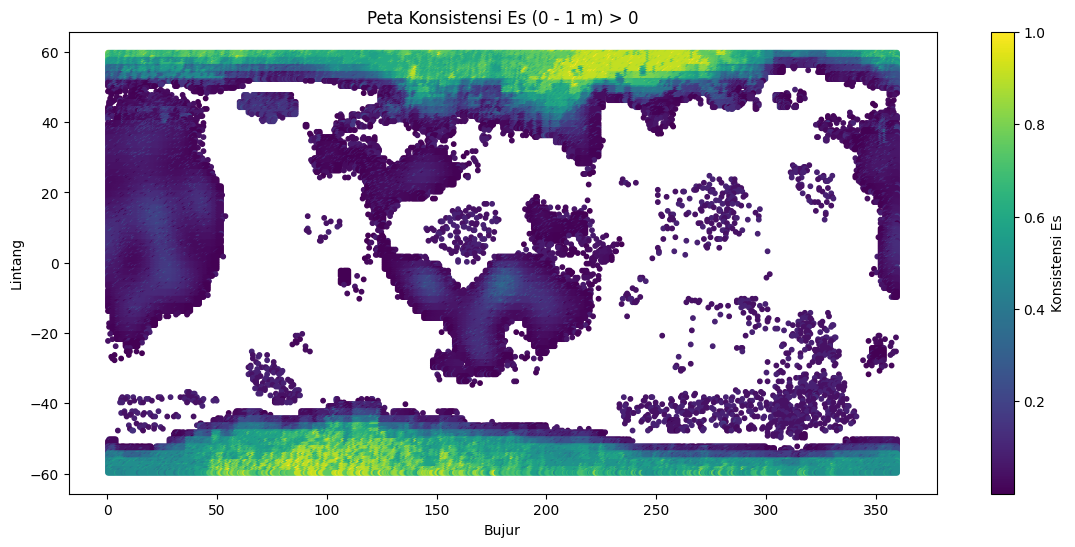

In [5]:
# Plot data
plt.figure(figsize=(14, 6))
plt.scatter(df_after0["Longitude"], df_after0["Latitude"], c=df_after0["Ice_Consistency"], cmap="viridis", s=10)
plt.colorbar(label="Konsistensi Es")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Konsistensi Es (0 - 1 m) > 0")


plt.show()